# DEPICT Module 2D — lightweight posthoc analysis

Run the SLURM batch computation first. This notebook loads saved outputs only; it does not rerun PCA, kNN, permutation, bootstrap, or matched-null computation.


## Note about the sensitivity-summary file

The completed heavy-computation outputs already contain everything needed to reconstruct
`k10_k30_k50_sensitivity_summary.csv`.

That file is only a lightweight derived summary. Its absence does **not** mean the SLURM
computation failed. This notebook now reconstructs it automatically from:

- `categorical_local_organization_results.csv`
- `dose_local_organization_results.csv`

and saves the reconstructed CSV back into the batch-output folder.


In [ ]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MAIN_DIR = Path(
    "~/DEPICT/Code/downstream_analysis_code/DGElandscape"
)
OUT_ROOT = (
    MAIN_DIR
    / "analysis"
    / "Module2D_QuantitativeLocalBiologicalOrganization"
)

# Files that are genuinely required for posthoc analysis.
required_core = [
    "categorical_local_organization_results.csv",
    "dose_local_organization_results.csv",
    "primary_k30_publication_summary.csv",
    "all_null_distributions_B1000.parquet",
]

missing_core = [
    f for f in required_core
    if not (OUT_ROOT / f).exists()
]

if missing_core:
    raise FileNotFoundError(
        "Batch job is missing required core outputs: "
        + ", ".join(missing_core)
    )

categorical = pd.read_csv(
    OUT_ROOT / "categorical_local_organization_results.csv"
)
dose = pd.read_csv(
    OUT_ROOT / "dose_local_organization_results.csv"
)
primary = pd.read_csv(
    OUT_ROOT / "primary_k30_publication_summary.csv"
)
nulls = pd.read_parquet(
    OUT_ROOT / "all_null_distributions_B1000.parquet"
)

# -------------------------------------------------------------------------
# Sensitivity file is convenient but NOT a heavy-computation output.
# If the batch script did not save it, reconstruct it exactly from the
# already-computed categorical and dose result tables.
# -------------------------------------------------------------------------
sensitivity_path = (
    OUT_ROOT
    / "k10_k30_k50_sensitivity_summary.csv"
)

if sensitivity_path.exists():
    sensitivity = pd.read_csv(
        sensitivity_path
    )
    print(
        "Loaded existing sensitivity summary:",
        sensitivity_path,
    )

else:
    print(
        "Sensitivity summary file was not saved by the batch script.\n"
        "Reconstructing it from the completed categorical and dose results..."
    )

    sensitivity_rows = []

    for _, r in categorical.iterrows():
        sensitivity_rows.append({
            "endpoint": r["endpoint"],
            "k": int(r["k"]),
            "normalized_effect": (
                r["enrichment_ratio_observed_over_null"]
                - 1.0
            ),
            "effect_definition": (
                "observed/null agreement - 1"
            ),
            "empirical_p": r["empirical_p_upper"],
        })

    for _, r in dose.iterrows():
        sensitivity_rows.append({
            "endpoint": "Dose",
            "k": int(r["k"]),
            "normalized_effect": (
                r[
                    "dose_organization_1_minus_observed_over_null"
                ]
            ),
            "effect_definition": (
                "1 - observed/null distance"
            ),
            "empirical_p": r["empirical_p_lower"],
        })

    sensitivity = (
        pd.DataFrame(sensitivity_rows)
        .sort_values(
            ["endpoint", "k"]
        )
        .reset_index(drop=True)
    )

    # Save the reconstructed lightweight summary so future runs can load it directly.
    sensitivity.to_csv(
        sensitivity_path,
        index=False,
    )

    print(
        "Reconstructed and saved:",
        sensitivity_path,
    )

print("\nLoaded completed batch outputs from:")
print(OUT_ROOT)

print("\nPrimary k=30 results:")
display(primary)

print("\nk=10/30/50 sensitivity table:")
display(sensitivity)


Sensitivity summary file was not saved by the batch script.
Reconstructing it from the completed categorical and dose results...
Reconstructed and saved: /work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DGEStructureAnalysis/Module2D_QuantitativeLocalBiologicalOrganization/k10_k30_k50_sensitivity_summary.csv

Loaded completed batch outputs from:
/work/users/m/e/meisheng/Dissertation/Experiments_Feb152025/code/transformer/Jul7WholeData/Jun2026New/analysis/DGEStructureAnalysis/Module2D_QuantitativeLocalBiologicalOrganization

Primary k=30 results:


,endpoint,k,effect_definition,normalized_effect,observed_raw,null_raw,absolute_difference,empirical_p,n_queries,n_unique_query_drugs
0,Broad MoA,30,observed/null agreement ratio,1.112651,0.333882,0.158039,0.175843,0.000999,92703,1193
1,Cell line,30,observed/null agreement ratio,3.504461,0.594228,0.131920,0.462308,0.000999,92703,1193
2,Duration (6h vs 24h),30,observed/null agreement ratio,0.449597,0.807947,0.557360,0.250587,0.000999,92202,1193
3,Dose,30,1 - observed/null log-dose distance,0.137822,0.635303,0.736859,0.101556,0.000999,85201,830



k=10/30/50 sensitivity table:


,endpoint,k,normalized_effect,effect_definition,empirical_p
0,Broad MoA,10,1.199345,observed/null agreement - 1,0.000999
1,Broad MoA,30,1.112651,observed/null agreement - 1,0.000999
2,Broad MoA,50,1.067877,observed/null agreement - 1,0.000999
3,Cell line,10,4.804897,observed/null agreement - 1,0.000999
4,Cell line,30,3.504461,observed/null agreement - 1,0.000999
5,Cell line,50,2.988640,observed/null agreement - 1,0.000999
6,Dose,10,0.196763,1 - observed/null distance,0.000999
7,Dose,30,0.137822,1 - observed/null distance,0.000999
8,Dose,50,0.106900,1 - observed/null distance,0.000999
9,Duration (6h vs 24h),10,0.604564,observed/null agreement - 1,0.000999


In [2]:
display(categorical)
display(dose)

,endpoint,k,n_queries,n_unique_query_drugs,observed_agreement,null_mean_agreement,absolute_observed_minus_null,enrichment_ratio_observed_over_null,bootstrap_ci95_low_observed_agreement,bootstrap_ci95_high_observed_agreement,empirical_p_upper,B_permutation,B_bootstrap
0,Broad MoA,10,92703,1193,0.351545,0.159841,0.191704,2.199345,0.316766,0.393071,0.000999,1000,1000
1,Broad MoA,30,92703,1193,0.333882,0.158039,0.175843,2.112651,0.295094,0.376302,0.000999,1000,1000
2,Broad MoA,50,92703,1193,0.325514,0.157415,0.168100,2.067877,0.290950,0.367469,0.000999,1000,1000
3,Cell line,10,92703,1193,0.773828,0.133306,0.640522,5.804897,0.761469,0.787519,0.000999,1000,1000
4,Cell line,30,92703,1193,0.594228,0.131920,0.462308,4.504461,0.576178,0.617824,0.000999,1000,1000
5,Cell line,50,92703,1193,0.524182,0.131419,0.392764,3.988640,0.503999,0.549515,0.000999,1000,1000
6,Duration (6h vs 24h),10,92202,1193,0.902633,0.562541,0.340092,1.604564,0.895721,0.910335,0.000999,1000,1000
7,Duration (6h vs 24h),30,92202,1193,0.807947,0.557360,0.250587,1.449597,0.798819,0.818404,0.000999,1000,1000
8,Duration (6h vs 24h),50,92202,1193,0.771636,0.555246,0.216391,1.389721,0.761620,0.784645,0.000999,1000,1000


,endpoint,k,n_queries,n_unique_query_drugs,observed_mean_abs_log10dose_difference,null_mean_abs_log10dose_difference,absolute_null_minus_observed,dose_organization_1_minus_observed_over_null,bootstrap_ci95_low_observed_distance,bootstrap_ci95_high_observed_distance,empirical_p_lower,B_random_null,B_bootstrap
0,Dose,10,92223,1109,0.547196,0.681238,0.134043,0.196763,0.511928,0.576599,0.000999,1000,1000
1,Dose,30,85201,830,0.635303,0.736859,0.101556,0.137822,0.597008,0.668208,0.000999,1000,1000
2,Dose,50,75833,581,0.725865,0.812748,0.086883,0.106900,0.676208,0.763687,0.000999,1000,1000


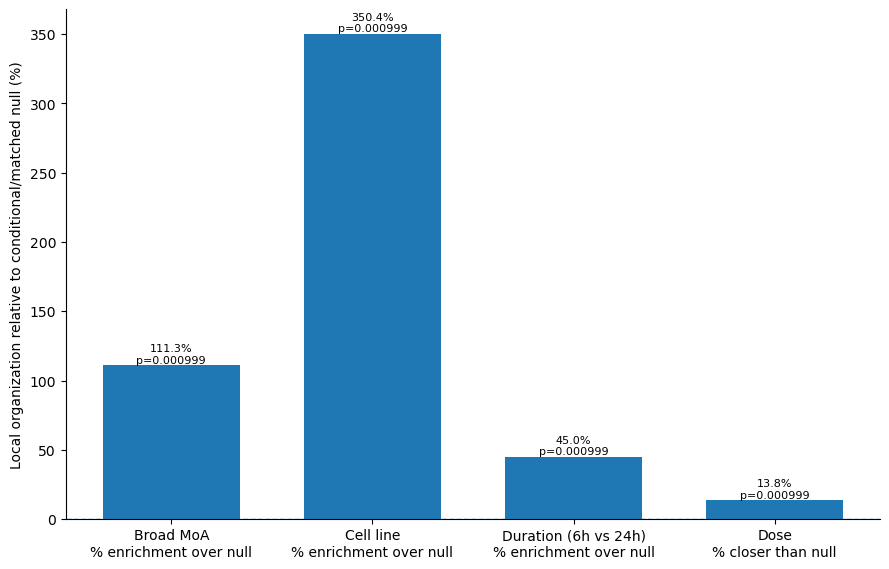

In [3]:
# Primary k=30 summary figure
values = 100 * primary["normalized_effect"].to_numpy()
x = np.arange(len(primary))
labels = ["Dose\n% closer than null" if e == "Dose" else f"{e}\n% enrichment over null" for e in primary["endpoint"]]
fig, ax = plt.subplots(figsize=(9,5.8))
bars = ax.bar(x, values, width=0.68)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Local organization relative to conditional/matched null (%)")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
for bar, value, pval in zip(bars, values, primary["empirical_p"]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f"{value:.1f}%\np={pval:.4g}", ha="center", va="bottom" if value >= 0 else "top", fontsize=8)
fig.tight_layout()
fig.savefig(OUT_ROOT/"Primary_k30_LocalBiologicalOrganization_Summary.pdf", bbox_inches="tight")
plt.show()

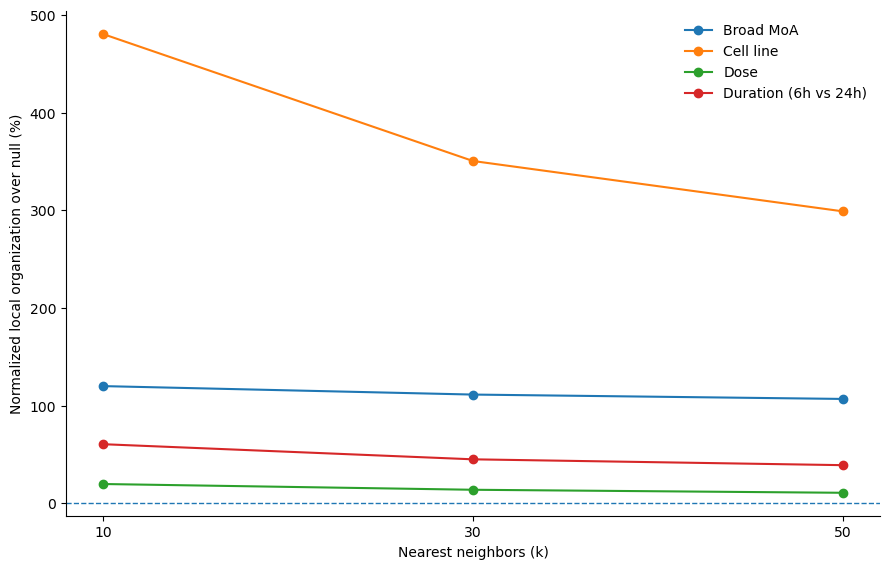

In [4]:
# k sensitivity
fig, ax = plt.subplots(figsize=(9,5.8))
for endpoint, sub in sensitivity.groupby("endpoint"):
    sub = sub.sort_values("k")
    ax.plot(sub["k"], 100*sub["normalized_effect"], marker="o", label=endpoint)
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_xticks(sorted(sensitivity["k"].unique()))
ax.set_xlabel("Nearest neighbors (k)")
ax.set_ylabel("Normalized local organization over null (%)")
ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
fig.savefig(OUT_ROOT/"Sensitivity_k10_k30_k50.pdf", bbox_inches="tight")
plt.show()

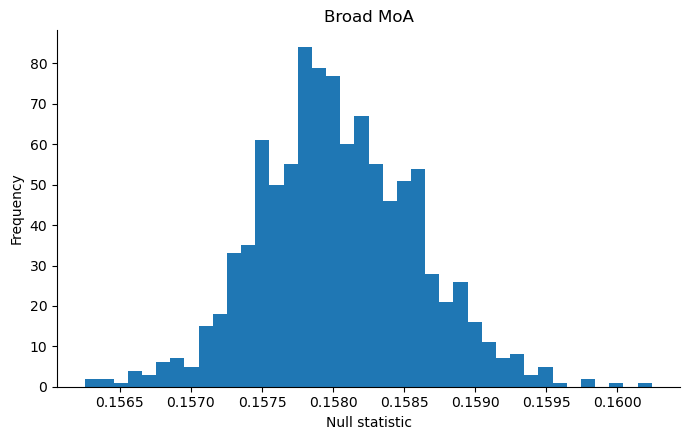

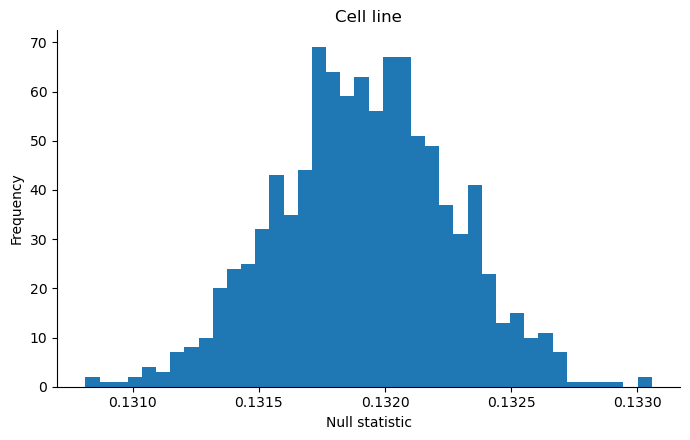

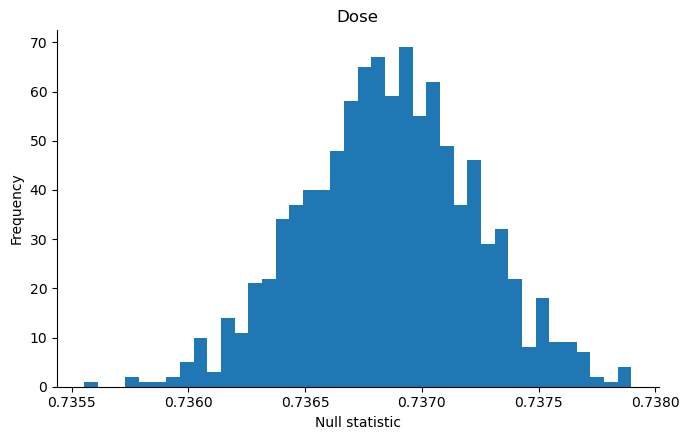

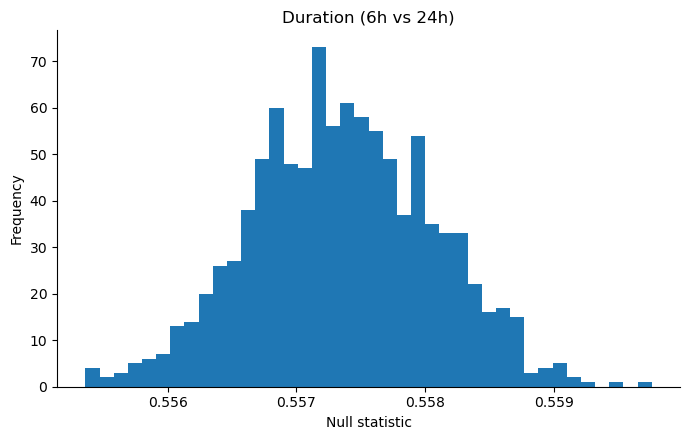

In [5]:
# Inspect B=1000 primary null distributions
for endpoint, sub in nulls.loc[nulls["k"].eq(30)].groupby("endpoint"):
    fig, ax = plt.subplots(figsize=(7,4.5))
    ax.hist(sub["null_statistic"], bins=40)
    ax.set_title(endpoint); ax.set_xlabel("Null statistic"); ax.set_ylabel("Frequency")
    ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
    fig.tight_layout(); plt.show()